# Redes neuronales convolucionales: de MNIST a imágenes reales

En este cuaderno vas a trabajar con redes neuronales convolucionales, conocidas como CNNs. Primero usamos MNIST porque es un dataset pequeño y controlado. Luego pasamos a `cats_vs_dogs`, que tiene imágenes reales y por eso introduce desafíos más cercanos a una aplicación práctica.

## Objetivos de aprendizaje

Al finalizar este cuaderno, vas a poder:

- explicar qué aporta una capa convolucional;
- entrenar una CNN para clasificar dígitos escritos a mano;
- evaluar el modelo con datos de prueba;
- comparar imágenes controladas con imágenes reales;
- identificar riesgos de sobreajuste y sesgos en datasets visuales.

## Microglosario

- **Píxel**: unidad mínima de una imagen digital.
- **Canal**: componente de color de una imagen. Una imagen en escala de grises tiene 1 canal; una imagen RGB tiene 3.
- **Filtro**: conjunto de valores que recorre la imagen para detectar patrones locales.
- **Convolución**: operación que aplica filtros sobre la imagen.
- **Pooling**: reducción del tamaño espacial de una representación.
- **Flatten**: transformación de una matriz en un vector.
- **Softmax**: salida probabilística para varias clases.
- **Sigmoid**: salida probabilística para clasificación binaria.

# Parte A. CNN con MNIST

MNIST contiene imágenes de dígitos escritos a mano del 0 al 9. Es un buen primer caso porque las imágenes son pequeñas, están centradas y tienen poca variabilidad de fondo.

## 1. Importar herramientas

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds

## 2. Cargar el dataset MNIST

In [2]:
datos_mnist, metadatos_mnist = tfds.load(
    "mnist",
    as_supervised=True,
    with_info=True,
)

nombres_clases_mnist = metadatos_mnist.features["label"].names
cantidad_mnist_entrenamiento = metadatos_mnist.splits["train"].num_examples
cantidad_mnist_prueba = metadatos_mnist.splits["test"].num_examples

print("Imágenes de entrenamiento:", cantidad_mnist_entrenamiento)
print("Imágenes de prueba:", cantidad_mnist_prueba)
print("Clases:", nombres_clases_mnist)

Imágenes de entrenamiento: 60000
Imágenes de prueba: 10000
Clases: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


**Consigna de lectura:** observá la cantidad de ejemplos. ¿Por qué ayuda tener muchas imágenes para entrenar un modelo?

## 3. Separar y normalizar datos

Normalizamos los píxeles para que sus valores queden entre 0 y 1. Esto suele facilitar el entrenamiento.

In [3]:
def normalizar_mnist(imagen, etiqueta):
    imagen = tf.cast(imagen, tf.float32)
    imagen = imagen / 255.0
    return imagen, etiqueta


datos_mnist_entrenamiento = datos_mnist["train"]
datos_mnist_prueba = datos_mnist["test"]

datos_mnist_entrenamiento = datos_mnist_entrenamiento.map(normalizar_mnist)
datos_mnist_prueba = datos_mnist_prueba.map(normalizar_mnist)

datos_mnist_entrenamiento = datos_mnist_entrenamiento.cache()
datos_mnist_prueba = datos_mnist_prueba.cache()

print("MNIST normalizado.")

MNIST normalizado.


## 4. Visualizar ejemplos

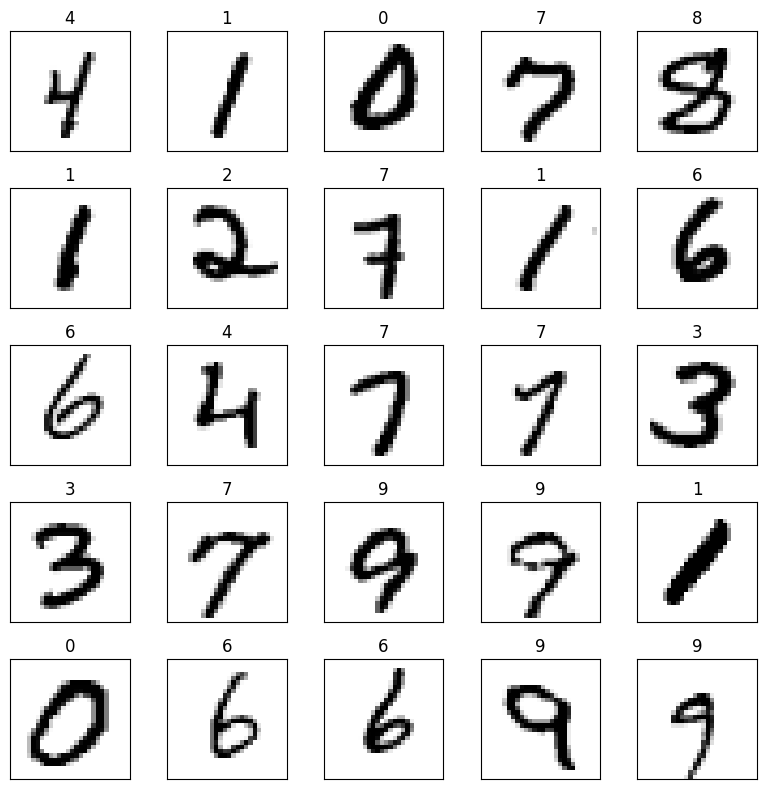

In [4]:
plt.figure(figsize=(8, 8))

for indice, (imagen, etiqueta) in enumerate(datos_mnist_entrenamiento.take(25)):
    plt.subplot(5, 5, indice + 1)
    plt.imshow(imagen[:, :, 0], cmap=plt.cm.binary)
    plt.xticks([])
    plt.yticks([])
    plt.title(nombres_clases_mnist[etiqueta.numpy()])

plt.tight_layout()
plt.show()

**Consigna de lectura:** mirá la variedad de escrituras. ¿Qué dígitos parecen más fáciles o más difíciles de distinguir?

## 5. Construir una CNN

Una CNN conserva la estructura espacial de la imagen durante las primeras capas. Esto permite detectar bordes, curvas y combinaciones de patrones locales antes de clasificar.

In [5]:
modelo_mnist = tf.keras.Sequential([
    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        input_shape=(28, 28, 1),
    ),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=100, activation="relu"),
    tf.keras.layers.Dense(units=10, activation="softmax"),
])

modelo_mnist.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

modelo_mnist.summary()

c:\Users\Cynthia\Desktop\ifts24-lab-pdi-2026-CYNTHIA\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       160,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 179,926 (702.84 KB)

 Trainable params: 179,926 (702.84 KB)

 Non-trainable params: 0 (0.00 B)

**Consigna de lectura:** identificá dónde aparecen las capas convolucionales, las capas de pooling y las capas densas.

## 6. Preparar lotes y entrenar

In [6]:
TAMANO_LOTE = 32
EPOCAS_MNIST = 5

lotes_mnist_entrenamiento = datos_mnist_entrenamiento.shuffle(cantidad_mnist_entrenamiento)
lotes_mnist_entrenamiento = lotes_mnist_entrenamiento.batch(TAMANO_LOTE)
lotes_mnist_entrenamiento = lotes_mnist_entrenamiento.prefetch(tf.data.AUTOTUNE)

lotes_mnist_prueba = datos_mnist_prueba.batch(TAMANO_LOTE)
lotes_mnist_prueba = lotes_mnist_prueba.prefetch(tf.data.AUTOTUNE)

historial_mnist = modelo_mnist.fit(
    lotes_mnist_entrenamiento,
    epochs=EPOCAS_MNIST,
    validation_data=lotes_mnist_prueba,
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9607 - loss: 0.1285 - val_accuracy: 0.9830 - val_loss: 0.0501
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9864 - loss: 0.0444 - val_accuracy: 0.9901 - val_loss: 0.0319
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9906 - loss: 0.0294 - val_accuracy: 0.9911 - val_loss: 0.0282
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9929 - loss: 0.0216 - val_accuracy: 0.9906 - val_loss: 0.0311
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9941 - loss: 0.0176 - val_accuracy: 0.9894 - val_loss: 0.0372


## 7. Evaluar MNIST

In [7]:
perdida_mnist, precision_mnist = modelo_mnist.evaluate(lotes_mnist_prueba)

print(f"Pérdida en prueba: {perdida_mnist:.4f}")
print(f"Precisión en prueba: {precision_mnist:.4f}")
print(f"Precisión equivalente: {precision_mnist * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9894 - loss: 0.0372
Pérdida en prueba: 0.0372
Precisión en prueba: 0.9894
Precisión equivalente: 98.94%


**Consigna de lectura:** compará este resultado con una red densa simple. ¿Qué ventaja esperás de una CNN en imágenes?

## 8. Visualizar predicciones de MNIST

In [8]:
for imagenes_prueba, etiquetas_prueba in lotes_mnist_prueba.take(1):
    imagenes_prueba = imagenes_prueba.numpy()
    etiquetas_prueba = etiquetas_prueba.numpy()
    probabilidades_mnist = modelo_mnist.predict(imagenes_prueba, verbose=0)
    break


def graficar_imagen_mnist(indice, probabilidades, etiquetas_reales, imagenes):
    probabilidades_imagen = probabilidades[indice]
    etiqueta_real = etiquetas_reales[indice]
    imagen = imagenes[indice]

    etiqueta_predicha = np.argmax(probabilidades_imagen)
    confianza = np.max(probabilidades_imagen)

    if etiqueta_predicha == etiqueta_real:
        color = "blue"
    else:
        color = "red"

    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(imagen[:, :, 0], cmap=plt.cm.binary)
    plt.xlabel(
        f"Predicción: {nombres_clases_mnist[etiqueta_predicha]} ({confianza * 100:.0f}%)
Real: {nombres_clases_mnist[etiqueta_real]}",
        color=color,
    )


filas = 3
columnas = 5
cantidad_imagenes = filas * columnas

plt.figure(figsize=(2 * columnas + 1, 2 * filas + 2))
plt.suptitle("Predicciones sobre MNIST", fontsize=14)

for indice in range(cantidad_imagenes):
    plt.subplot(filas, columnas, indice + 1)
    graficar_imagen_mnist(indice, probabilidades_mnist, etiquetas_prueba, imagenes_prueba)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

SyntaxError: unterminated string literal (detected at line 26) (2557020560.py, line 26)

**Consigna de lectura:** elegí una predicción incorrecta, si aparece. ¿El error resulta comprensible visualmente?

# Parte B. CNN con imágenes reales: gatos y perros

Ahora pasamos a un caso menos controlado. Las imágenes de gatos y perros tienen fondos, tamaños, posturas e iluminaciones muy variadas. Esto acerca el problema a la creación de datasets propios.

## 9. Cargar `cats_vs_dogs`

Este dataset puede tardar en descargarse la primera vez. Si la conexión es inestable, conviene ejecutar esta parte con anticipación.

In [1]:
#reiniciar el kernel para evitar conflictos con el siguiente ejercicio
#si la carpeta con la descarga queda a medias,
#eliminarla y volver a ejecutar esta celda para descargarla nuevamente

import math

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds


datos_animales, metadatos_animales = tfds.load(
    "cats_vs_dogs",
    as_supervised=True,
    with_info=True
)

datos_animales = datos_animales["train"]

nombres_clases_animales = metadatos_animales.features["label"].names
cantidad_animales = metadatos_animales.splits["train"].num_examples

print("Cantidad total de imágenes:", cantidad_animales)
print("Clases:", nombres_clases_animales)




Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

KeyError: "There is no item named 'PetImages\\\\Cat\\\\0.jpg' in the archive"

In [ ]:
nombres_clases_animales = metadatos_animales.features["label"].names
cantidad_animales = metadatos_animales.splits["train"].num_examples

print("Cantidad total de imágenes:", cantidad_animales)
print("Clases:", nombres_clases_animales)

In [2]:
nombres_clases_animales = metadatos_animales.features["label"].names
cantidad_animales = metadatos_animales.splits["train"].num_examples

print("Cantidad total de imágenes:", cantidad_animales)
print("Clases:", nombres_clases_animales)

NameError: name 'metadatos_animales' is not defined

**Consigna de lectura:** pensá qué diferencias hay entre clasificar dígitos centrados y clasificar fotos reales tomadas en contextos variados.

## 10. Visualizar imágenes reales

In [ ]:
plt.figure(figsize=(10, 10))

for indice, (imagen, etiqueta) in enumerate(datos_animales["train"].take(16)):
    plt.subplot(4, 4, indice + 1)
    plt.imshow(imagen.numpy())
    plt.xticks([])
    plt.yticks([])
    plt.title(nombres_clases_animales[etiqueta.numpy()])

plt.tight_layout()
plt.show()

**Consigna de lectura:** observá fondos, encuadres e iluminación. ¿Qué podría aprender mal el modelo si el dataset estuviera sesgado?

## 11. Preprocesar imágenes reales

Para simplificar el entrenamiento, redimensionamos todas las imágenes a 100 x 100 píxeles y las convertimos a escala de grises. Esta decisión reduce información de color, pero facilita la comparación con los ejemplos anteriores.

In [ ]:
TAMANO_IMAGEN = 100


def preprocesar_animal(imagen, etiqueta):
    imagen = tf.image.resize(imagen, (TAMANO_IMAGEN, TAMANO_IMAGEN))
    imagen = tf.image.rgb_to_grayscale(imagen)
    imagen = tf.cast(imagen, tf.float32)
    imagen = imagen / 255.0
    return imagen, etiqueta


datos_animales_procesados = datos_animales["train"].map(preprocesar_animal)
datos_animales_procesados = datos_animales_procesados.cache()

print("Imágenes redimensionadas, convertidas a escala de grises y normalizadas.")

## 12. Separar entrenamiento y validación

Como `cats_vs_dogs` viene con una sola partición principal, armamos una separación simple: una parte para entrenar y otra para validar.

In [ ]:
cantidad_validacion = int(cantidad_animales * 0.15)
cantidad_entrenamiento_animales = cantidad_animales - cantidad_validacion

lotes_animales_validacion = datos_animales_procesados.take(cantidad_validacion)
lotes_animales_entrenamiento = datos_animales_procesados.skip(cantidad_validacion)

lotes_animales_entrenamiento = lotes_animales_entrenamiento.shuffle(cantidad_entrenamiento_animales)
lotes_animales_entrenamiento = lotes_animales_entrenamiento.batch(TAMANO_LOTE)
lotes_animales_entrenamiento = lotes_animales_entrenamiento.prefetch(tf.data.AUTOTUNE)

lotes_animales_validacion = lotes_animales_validacion.batch(TAMANO_LOTE)
lotes_animales_validacion = lotes_animales_validacion.prefetch(tf.data.AUTOTUNE)

print("Imágenes para entrenamiento:", cantidad_entrenamiento_animales)
print("Imágenes para validación:", cantidad_validacion)

## 13. Construir la CNN para gatos y perros

Como este problema tiene dos clases, usamos una neurona de salida con activación `sigmoid`. El resultado se interpreta como probabilidad de la clase 1.

In [ ]:
modelo_animales = tf.keras.Sequential([
    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        input_shape=(TAMANO_IMAGEN, TAMANO_IMAGEN, 1),
    ),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=100, activation="relu"),
    tf.keras.layers.Dense(units=1, activation="sigmoid"),
])

modelo_animales.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

modelo_animales.summary()

**Consigna de lectura:** compará esta salida con la de MNIST. ¿Por qué ahora hay una sola neurona final?

## 14. Entrenar y evaluar con imágenes reales

Usamos pocas épocas para que el cuaderno sea viable en clase. Podés aumentar este valor en una experimentación posterior.

In [ ]:
EPOCAS_ANIMALES = 5

historial_animales = modelo_animales.fit(
    lotes_animales_entrenamiento,
    epochs=EPOCAS_ANIMALES,
    validation_data=lotes_animales_validacion,
)

perdida_animales, precision_animales = modelo_animales.evaluate(lotes_animales_validacion)

print(f"Pérdida en validación: {perdida_animales:.4f}")
print(f"Precisión en validación: {precision_animales:.4f}")

**Consigna de lectura:** si la precisión de entrenamiento supera mucho a la de validación, puede haber sobreajuste.

## 15. Visualizar predicciones de gatos y perros

In [ ]:
for imagenes_animales, etiquetas_animales in lotes_animales_validacion.take(1):
    imagenes_animales = imagenes_animales.numpy()
    etiquetas_animales = etiquetas_animales.numpy()
    probabilidades_animales = modelo_animales.predict(imagenes_animales, verbose=0)
    break


def graficar_imagen_animal(indice, probabilidades, etiquetas_reales, imagenes):
    probabilidad_clase_uno = probabilidades[indice][0]
    etiqueta_real = etiquetas_reales[indice]
    imagen = imagenes[indice]

    if probabilidad_clase_uno > 0.5:
        etiqueta_predicha = 1
    else:
        etiqueta_predicha = 0

    if etiqueta_predicha == etiqueta_real:
        color = "blue"
    else:
        color = "red"

    if etiqueta_predicha == 1:
        confianza = probabilidad_clase_uno
    else:
        confianza = 1 - probabilidad_clase_uno

    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(np.squeeze(imagen), cmap=plt.cm.gray)
    plt.xlabel(
        f"Predicción: {nombres_clases_animales[etiqueta_predicha]} ({confianza * 100:.0f}%)
Real: {nombres_clases_animales[etiqueta_real]}",
        color=color,
    )


filas = 3
columnas = 5
cantidad_imagenes = filas * columnas

plt.figure(figsize=(2 * columnas + 1, 2 * filas + 2))
plt.suptitle("Predicciones sobre gatos y perros", fontsize=14)

for indice in range(cantidad_imagenes):
    plt.subplot(filas, columnas, indice + 1)
    graficar_imagen_animal(indice, probabilidades_animales, etiquetas_animales, imagenes_animales)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Consigna de lectura:** revisá los errores. ¿Parecen vinculados al animal, al fondo, al encuadre o a la iluminación?

## 16. Métodos para mejorar el rendimiento

Cuando un modelo falla o sobreajusta, podés probar estas estrategias:

- aumentar la variedad del dataset;
- balancear la cantidad de imágenes por clase;
- agregar aumento de datos;
- usar dropout;
- entrenar más épocas solo si la validación también mejora;
- revisar imágenes problemáticas o mal etiquetadas.

## Cierre

En este cuaderno pasaste de imágenes controladas a imágenes reales. Esa transición es importante para entender por qué la calidad del dataset afecta tanto al resultado.

El próximo paso será crear datasets propios, entrenarlos con Teachable Machine y exportar el modelo para usarlo en una interfaz con Gradio.